# Proyecto final · Titanic

**Estadística Descriptiva e Inferencial**

Integrantes: Roberto Javier Mangas Flores, Jorge Callalle Torres     
Fecha: 31/08/2026

---

## Qué se te pide

Construir un modelo de clasificación **paso a paso**, midiendo qué aporta cada variable
que agregas, y presentar tus hallazgos en 5 slides.

> **No se evalúa qué tan bueno sea tu modelo.** Se evalúa qué entendiste: por qué cada
> variable aporta o no, qué pasa cuando falta una, y cómo justificas tus decisiones.

## Las tres partes

| Parte | Min | Qué haces |
|---|---|---|
| 1 | 45 | Reconocimiento: mirar los datos y escribir tres hipótesis |
| 2 | 100 | **Seis modelos incrementales y qué cambia en cada paso** |
| 3 | 45 | Elegir un umbral y justificarlo |

Después, la presentación: 5 slides, 7 minutos.


---
## Celda 0 · Preparación

Carga los datos y prepara las variables que vas a usar.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings("ignore")

NAVY, BLUE, MAG, GREEN = "#0A2559", "#1A56E8", "#E6115E", "#12B886"
plt.rcParams.update(
    {"figure.figsize": (7, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})

URL = ("https://raw.githubusercontent.com/josefrodrim/"
       "Estad-stica-Descriptiva-E-Inferencial/main/"
       "Proyecto_final_titanic/Data/Titanic-Dataset.csv")

try:
    titanic = pd.read_csv(URL)
    print("Datos cargados desde el repo del curso.")
except Exception:
    titanic = pd.read_csv("Titanic-Dataset.csv")
    print("Datos cargados desde archivo local.")

# Dataset de trabajo
d = titanic.copy()

# Variable numerica para sexo: 1 = mujer, 0 = hombre
d["sex"] = (d["Sex"] == "female").astype(int)

# Variable numerica para edad: se rellenan faltantes con la mediana
d["age"] = d["Age"].fillna(d["Age"].median())

# Alias para mantener compatibilidad con explicaciones/celdas posteriores
datos = d

# Variables finales del proyecto
X = d[["sex", "Pclass", "age", "Fare"]]
y = d["Survived"]

print(f"\n{len(datos)} pasajeros")
print(d[["Survived", "sex", "Pclass", "age", "Fare"]].head())


# ── Variables ya preparadas para ti ──────────────────────────────────────
#d = titanic.copy()
#d["mujer"] = (d["Sex"] == "female").astype(int)
#d["edad"] = d["Age"].fillna(d["Age"].median())     # <- ojo con esto, ver Parte 1
#d["familia"] = d["SibSp"] + d["Parch"]             # hermanos/pareja + padres/hijos
#d["tiene_camarote"] = d["Cabin"].notna().astype(int)

#print(f"\n{len(d)} pasajeros")
#print(d[["Survived", "mujer", "Pclass", "edad", "familia", "tiene_camarote"]].head())

Datos cargados desde el repo del curso.

891 pasajeros
   Survived  sex  Pclass   age     Fare
0         0    0       3  22.0   7.2500
1         1    1       1  38.0  71.2833
2         1    1       3  26.0   7.9250
3         1    1       1  35.0  53.1000
4         0    0       3  35.0   8.0500


### Las variables que vas a usar

| Variable | Qué es |
|---|---|
| `Survived` | **1 sobrevivió, 0 no.** Es lo que predices |
| `sex` | 1 si es mujer |
| `Pclass` | clase del billete: 1, 2 o 3 |
| `age` | Edad del Pasajero, en caso de dato vacío se coloca la mediana |
| `fare` | muestra la tarifa del pasajero |

---
# Parte 1 · Reconocimiento  ·  45 min  ·  15 puntos

Antes de modelar, mira los datos.

### 1.1 — Valores faltantes

In [4]:
# Cuenta los valores faltantes de cada columna del dataset ORIGINAL (titanic).
# Muestra solo las que tienen alguno.
faltantes = titanic.isna().sum()
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)
print("Columnas con valores faltantes:")
print(faltantes)



Columnas con valores faltantes:
Cabin       687
Age         177
Embarked      2
dtype: int64


### 1.2 — Tasas de supervivencia por grupo

In [13]:
# Calculamos la supervivencia general y luego por las variables que usaremos en
# el modelo.

print("Tasa de supervivencia general:")
print(f"{100 * datos['Survived'].mean():.2f} %")

print("\nTasa de supervivencia por sexo:")
print((datos.groupby("Sex")["Survived"].mean() * 100).round(2))

print("\nTasa de supervivencia por clase:")
print((datos.groupby("Pclass")["Survived"].mean() * 100).round(2))

print("\nResumen de Fare por resultado:")
print(datos.groupby("Survived")["Fare"].describe().round(2))


Tasa de supervivencia general:
38.38 %

Tasa de supervivencia por sexo:
Sex
female    74.20
male      18.89
Name: Survived, dtype: float64

Tasa de supervivencia por clase:
Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64

Resumen de Fare por resultado:
          count   mean    std  min    25%   50%   75%     max
Survived                                                     
0         549.0  22.12  31.39  0.0   7.85  10.5  26.0  263.00
1         342.0  48.40  66.60  0.0  12.48  26.0  57.0  512.33


**Dato**:

Entonces las mujeres tuvieron aproximadamente 3.9 veces más probabilidad observada de sobrevivir que los hombres.


```
74.2 / 18.9 ≈ 3.9
```



### 1.3 — Dos gráficos

Haz al menos dos. Sugerencias: tasa de supervivencia por clase y sexo, distribución de
edades por resultado, tasa de tarifa

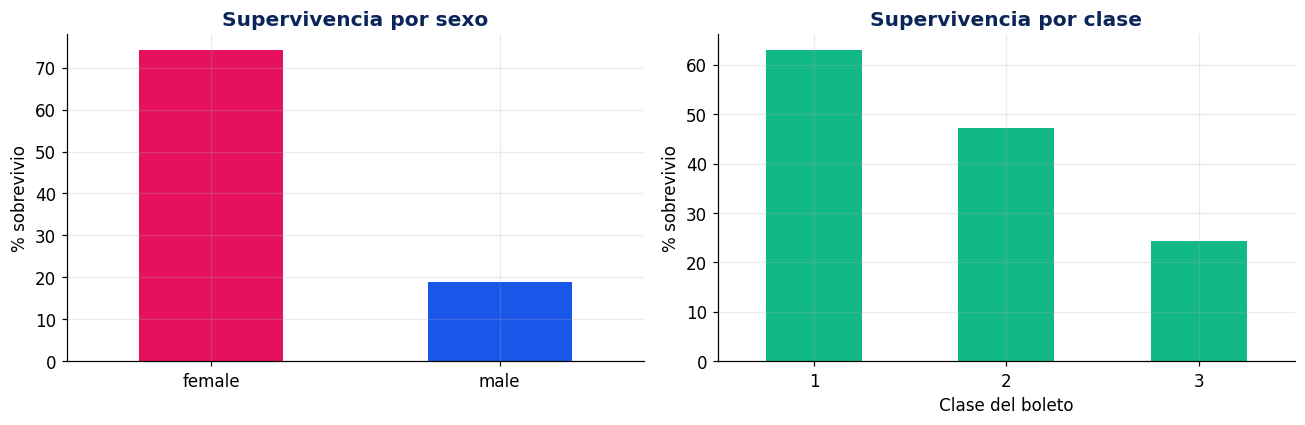

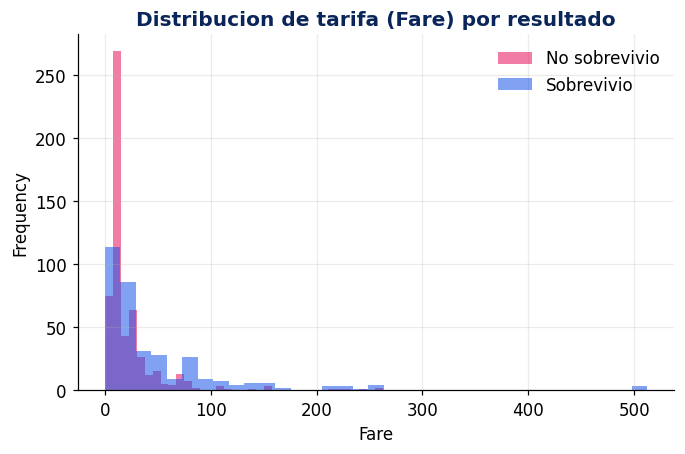

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

(datos.groupby("Sex")["Survived"].mean() * 100).plot(
    kind="bar", ax=axes[0], color=[MAG, BLUE]
)
axes[0].set_title("Supervivencia por sexo", color=NAVY, fontweight="bold")
axes[0].set_ylabel("% sobrevivio")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

(datos.groupby("Pclass")["Survived"].mean() * 100).plot(
    kind="bar", ax=axes[1], color=GREEN
)
axes[1].set_title("Supervivencia por clase", color=NAVY, fontweight="bold")
axes[1].set_ylabel("% sobrevivio")
axes[1].set_xlabel("Clase del boleto")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.2))
for sobrevivio, color, label in [(0, MAG, "No sobrevivio"), (1, BLUE, "Sobrevivio")]:
    datos.loc[datos["Survived"] == sobrevivio, "Fare"].plot(
        kind="hist", bins=35, alpha=0.55, color=color, label=label
    )
plt.title("Distribucion de tarifa (Fare) por resultado", color=NAVY, fontweight="bold")
plt.xlabel("Fare")
plt.legend(frameon=False)
plt.show()

### 1.4 — Tus tres hipótesis  

1. Las mujeres tendrán mayor probabilidad de sobrevivir que los hombres.
2. Los pasajeros de primera clase tendrán mayor probabilidad de sobrevivir que los de tercera clase.
3. Los pasajeros que pagaron tarifas más altas tenderán a tener mayor probabilidad de sobrevivir, aunque parte de ese efecto puede estar relacionado con la clase del boleto.

---
# Parte 2 · Seis modelos incrementales  ·  100 min  ·  40 puntos

Construimos modelos agregando una variable a la vez. Asi medimos que aporta cada variable.

| Modelo | Variables |
|---|---|
| M0 | ninguna: predecir siempre la clase mayoritaria |
| M1 | `sex` |
| M2 | `sex`, `Pclass` |
| M3 | `sex`, `Pclass`, `age` |
| M4 | `sex`, `Pclass`, `age`, `Fare` |

Las metricas se calculan siempre en datos de prueba.

### 2.1 — Separa los datos

Usa `test_size=0.3`, `random_state=42` y `stratify=y`. Es importante que uses estos
valores para que tu trabajo sea comparable con el de las otras parejas.

In [7]:
  # ── TU CÓDIGO ────────────────────────────────────────────────────────────

#X = d[["mujer", "Pclass", "edad", "familia", "tiene_camarote"]]
#y = d["Survived"]

#X_train, X_test, y_train, y_test = None, None, None, None

#print(f"train={len(X_train)}  test={len(X_test)}")

X = d[["sex", "Pclass", "age", "Fare"]]
y = d["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"train = {len(X_train)} pasajeros")
print(f"test  = {len(X_test)} pasajeros")
print(f"supervivencia en train = {100 * y_train.mean():.2f} %")
print(f"supervivencia en test  = {100 * y_test.mean():.2f} %")


train = 623 pasajeros
test  = 268 pasajeros
supervivencia en train = 38.36 %
supervivencia en test  = 38.43 %


Los porcentajes (38.36% train) y (38.43% test) son similares, Significa que el modelo se entrenará con una distribución de supervivencia que es consistente con la distribución que verá durante la evaluación en el conjunto de prueba. Esto es ideal porque el rendimiento que observes en el conjunto de prueba será una estimación más confiable de cómo se comportaría tu modelo con datos nuevos y no vistos.

### 2.2 — La tabla de los seis modelos

| Modelo | Variables |
|---|---|
| M0 | ninguna: predecir siempre la clase mayoritaria |
| M1 | `sex` |
| M2 | `sex`, `Pclass` |
| M3 | `sex`, `Pclass`, `age` |
| M4 | `sex`, `Pclass`, `age`, `Fare` |

Para cada modelo calculamos:

- **AUC**: mide que tan bien ordena el modelo a sobrevivientes por encima de no sobrevivientes.
- **Exactitud**: porcentaje de aciertos usando umbral 0.5.

In [9]:
modelos = {
    "M1": ["sex"],
    "M2": ["sex", "Pclass"],
    "M3": ["sex", "Pclass", "age"],
    "M4": ["sex", "Pclass", "age", "Fare"],
}

filas = []
modelos_entrenados = {}

# M0: regla trivial. Como la mayoria no sobrevivió, predice siempre 0.
pred_m0 = np.zeros(len(y_test), dtype=int)
filas.append({
    "modelo": "M0",
    "variables": "ninguna",
    "AUC": 0.5000,
    "exactitud": round(accuracy_score(y_test, pred_m0), 4),
})

for nombre, cols in modelos.items():
    modelo = LogisticRegression(max_iter=1000)
    modelo.fit(X_train[cols], y_train)
    modelos_entrenados[nombre] = modelo

    prob = modelo.predict_proba(X_test[cols])[:, 1]
    pred = (prob >= 0.5).astype(int)

    filas.append({
        "modelo": nombre,
        "variables": ", ".join(cols),
        "AUC": round(roc_auc_score(y_test, prob), 4),
        "exactitud": round(accuracy_score(y_test, pred), 4),
    })

tabla_modelos = pd.DataFrame(filas)
print(tabla_modelos.to_string(index=False))

modelo              variables    AUC  exactitud
    M0                ninguna 0.5000     0.6157
    M1                    sex 0.7580     0.7761
    M2            sex, Pclass 0.8301     0.7761
    M3       sex, Pclass, age 0.8375     0.7724
    M4 sex, Pclass, age, Fare 0.8395     0.7799


### 2.3 — Las tres preguntas  ·  **se califican**

**a) ¿Qué variable aportó más? ¿Y cuál casi nada?**
La variable que más aportó fue sex, porque la supervivencia fue muy diferente entre mujeres y hombres. Pclass también aportó bastante. La que aportó menos fue Fare, porque parte de su información ya está relacionada con Pclass.

**b) ¿Alguna hizo empeorar el modelo? ¿Cómo es posible que agregar información empeore?**

No, cada variable agregada fue modificando el valor AUC de manera incremental, identificado una incremento menor del M3 a M4.

-----
**Conclusiones:**
La comparacion correcta no es mirar solo el modelo final. Hay que mirar cuanto cambia el desempeno cuando agregamos cada variable.

- Si M1 mejora mucho frente a M0, entonces `sex` aporta bastante.
- Si M2 mejora frente a M1, entonces `Pclass` agrega informacion adicional al sexo.
- Si M3 mejora frente a M2, entonces `age` aporta informacion adicional despues de considerar sexo y clase.
- Si M4 mejora poco frente a M3, entonces `Fare` aporta poca informacion nueva despues de considerar sexo, clase y edad.

Esto ultimo puede pasar porque `Fare` y `Pclass` estan relacionadas: normalmente los boletos de primera clase cuestan mas que los de tercera clase.
>


### 2.4 — El hallazgo  ·  **20 puntos**


Ahora compara **los coeficientes de una misma variable entre modelos distintos**.

Busca una variable cuyo coeficiente cambie de forma llamativa —de tamaño, o incluso de
signo— al agregar otra variable al modelo.

**Pista:** fíjate en las variables que parecían no importar cuando estaban solas.

In [11]:
# Se realizó ajustes de los modelos con distintas combinaciones y se compara
# con el coeficiente de UNA MISMA variable entre ellos, se realizar con la
# variable 'sex' y despues se realiza las combinaciones.

filas_coef = []

for nombre, cols in modelos.items():
    modelo = modelos_entrenados[nombre]
    for variable, coef in zip(cols, modelo.coef_[0]):
        filas_coef.append({
            "modelo": nombre,
            "variable": variable,
            "coeficiente": round(coef, 4),
            "odds_ratio": round(np.exp(coef), 4),
        })

tabla_coef = pd.DataFrame(filas_coef)
print(tabla_coef.to_string(index=False))



modelo variable  coeficiente  odds_ratio
    M1      sex       2.4734     11.8629
    M2      sex       2.5488     12.7921
    M2   Pclass      -0.9056      0.4043
    M3      sex       2.5147     12.3627
    M3   Pclass      -1.1321      0.3223
    M3      age      -0.0371      0.9636
    M4      sex       2.4977     12.1550
    M4   Pclass      -1.0773      0.3405
    M4      age      -0.0365      0.9641
    M4     Fare       0.0019      1.0019


### 2.5 - Hallazgo esperado

Un hallazgo probable es que `Fare` no aporte tanto cuando ya estan `Pclass` y `age` en el modelo.

Esto no significa que la tarifa no tenga relacion con la supervivencia. Significa que parte de la informacion de `Fare` ya estaba capturada por `Pclass`. En otras palabras: la tarifa y la clase del boleto miden aspectos parecidos del nivel socioeconomico del pasajero.

**c) Describe el hallazgo: qué variable, cómo cambió, y por qué crees que pasa.**

**Analisis de tabla:**

- sex tiene odds ratio entre 11.86 y 12.79. Eso significa que ser mujer tiene muchas más chances de sobrevivir que ser hombre, manteniendo las demás variables del modelo.

- Pclass tiene odds ratio entre 0.32 y 0.40. Como es menor que 1, al aumentar la clase numérica, bajan las chances de sobrevivir. O sea, pasar de clase 1 a 2 o de 2 a 3 reduce la probabilidad de sobrevivir.

- age tiene odds ratio cerca de 0.96. Eso significa que cada año adicional de edad reduce un poco las chances de sobrevivir.

- Fare tiene odds ratio 1.0019. Está casi en 1, entonces casi no cambia las chances de sobrevivir cuando ya se consideran sexo, clase y edad.


**Hallazgo principal**:

La variable que más influye es sex: ser mujer aumenta mucho las chances de sobrevivir. Pclass también importa: las clases más bajas tuvieron menos supervivencia. Fare casi no aporta información nueva porque está muy relacionada con Pclass; quienes pagaban más normalmente estaban en mejor clase.


---
# Parte 3 · El umbral  ·  45 min  ·  15 puntos

## El escenario

Una **aseguradora** debe estimar cuántos pasajeros sobrevivirán, para saber cuánto dinero
provisionar para indemnizaciones a las familias de los fallecidos.

| Error | Qué pasa |
|---|---|
| **Falso positivo** — predije que sobrevive y murió | No se provisionó. Hay que pagar sin reserva: problema financiero serio |
| **Falso negativo** — predije que muere y sobrevivió | Se provisionó de más. Dinero inmovilizado que no se pudo usar |

Los dos cuestan, y no lo mismo.

Usa el mejor modelo de la Parte 2 (por AUC).

In [14]:
# ── TU CÓDIGO ────────────────────────────────────────────────────────────
# Prueba al menos cinco umbrales. Para cada uno muestra:
# VP, FP, FN, VN, exactitud, precisión y recall.

mejor_modelo = tabla_modelos.sort_values("AUC", ascending=False).iloc[0]["modelo"]
print(f"Mejor modelo por AUC: {mejor_modelo}")

cols_mejor = modelos[mejor_modelo]
modelo_final = modelos_entrenados[mejor_modelo]
prob_test = modelo_final.predict_proba(X_test[cols_mejor])[:, 1]
pred_05 = (prob_test >= 0.5).astype(int)

cm = confusion_matrix(y_test, pred_05)
vn, fp, fn, vp = cm.ravel()

exactitud = accuracy_score(y_test, pred_05)
precision = precision_score(y_test, pred_05, zero_division=0)
recall = recall_score(y_test, pred_05)
auc = roc_auc_score(y_test, prob_test)

print("Matriz de confusion con umbral 0.5")
print(f"{'':22}{'predijo MURIO':>16}{'predijo VIVIO':>16}")
print(f"{'realmente MURIO':22}{vn:>16}{fp:>16}")
print(f"{'realmente VIVIO':22}{fn:>16}{vp:>16}")
print()
print(f"AUC       = {auc:.4f}")
print(f"Exactitud = {exactitud:.4f}")
print(f"Precision = {precision:.4f}")
print(f"Recall    = {recall:.4f}")



Mejor modelo por AUC: M4
Matriz de confusion con umbral 0.5
                         predijo MURIO   predijo VIVIO
realmente MURIO                    133              32
realmente VIVIO                     27              76

AUC       = 0.8395
Exactitud = 0.7799
Precision = 0.7037
Recall    = 0.7379


### 3.1 - Probar varios umbrales

El umbral 0.5 no es obligatorio. Mover el umbral cambia el tipo de error que comete el modelo.
*texto en cursiva*






In [15]:
filas_umbral = []

for umbral in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred = (prob_test >= umbral).astype(int)
    vn_, fp_, fn_, vp_ = confusion_matrix(y_test, pred).ravel()

    filas_umbral.append({
        "umbral": umbral,
        "VP": vp_,
        "FP": fp_,
        "FN": fn_,
        "VN": vn_,
        "exactitud": round(accuracy_score(y_test, pred), 4),
        "precision": round(precision_score(y_test, pred, zero_division=0), 4),
        "recall": round(recall_score(y_test, pred), 4),
    })

tabla_umbral = pd.DataFrame(filas_umbral)
print(tabla_umbral.to_string(index=False))

 umbral  VP  FP  FN  VN  exactitud  precision  recall
    0.3  86  48  17 117     0.7575     0.6418  0.8350
    0.4  85  39  18 126     0.7873     0.6855  0.8252
    0.5  76  32  27 133     0.7799     0.7037  0.7379
    0.6  59  13  44 152     0.7873     0.8194  0.5728
    0.7  50   7  53 158     0.7761     0.8772  0.4854



**¿Qué umbral eliges y por qué? Conecta tu respuesta con el escenario de la aseguradora,
no con la exactitud.**

**Escribe aquí:**

> **Umbral elegido:**
>Umbral elegido: 0.6

> **Justificación:**

Con umbral 0.6, la exactitud es alta: 0.7873, igual que con 0.4, pero tiene menos falsos positivos: FP = 13. Esto es mejor para la aseguradora porque reduce el riesgo de pensar que alguien sobrevivió cuando en realidad falleció.







---
# Cierre  ·  15 puntos

### Vuelve a tus hipótesis

Regresa a la sección 1.4 y compara. **¿Cuáles se cumplieron y cuáles no?**

**Escribe aquí:**

>Con el contexto analizado, las tres hipótesis se cumplen, pero no con la misma fuerza.
1. **Las mujeres tendrán mayor probabilidad de sobrevivir que los hombres.**
   Sí se cumplió.
   Las mujeres tuvieron una supervivencia mucho mayor: aproximadamente 74 % frente a 19 % en los hombres. Además, en la regresión logística, sex tuvo un odds_ratio cercano a 12, lo que muestra que fue la variable con mayor efecto.
2. **Los pasajeros de primera clase tendrán mayor probabilidad de sobrevivir que los de tercera clase**.
   Sí se cumplió.
   La supervivencia fue mayor en primera clase y menor en tercera clase. Además, Pclass tuvo un coeficiente negativo y un odds_ratio menor que 1, lo que significa que al pasar a una clase numéricamente mayor, como de 1 a 2 o de 2 a 3, disminuyen las chances de sobrevivir.
3. **Los pasajeros que pagaron tarifas más altas tenderán a tener mayor probabilidad de sobrevivir**.
   Se cumplió parcialmente.
   En el análisis descriptivo, los sobrevivientes pagaron tarifas más altas en promedio. Sin embargo, en el modelo final, Fare tuvo un odds_ratio muy cercano a 1, por lo que aportó poca información adicional. Esto pasa porque Fare está relacionada con Pclass: quienes pagaban más normalmente estaban en mejores clases.


**Conclusión**:
Se cumplieron claramente las hipótesis sobre sex y Pclass. La hipótesis sobre Fare se cumplió solo de forma parcial, porque parece importante al verla sola, pero pierde fuerza cuando el modelo ya considera la clase del boleto.


### Tres limitaciones de tu análisis  ·  **15 puntos**



**Limitación 1**:
La variable age tenía valores faltantes y fueron reemplazados por la mediana. Esto permite completar el análisis, pero puede ocultar diferencias reales entre pasajeros y afectar la precisión del modelo.


**Limitación 2:**
El modelo muestra relaciones entre variables y supervivencia, pero no demuestra causalidad. Por ejemplo, que las mujeres hayan sobrevivido más no significa que el sexo por sí solo sea la única causa; también influyeron decisiones de rescate, clase social, ubicación en el barco y otros factores no incluidos.


**Limitación 3:**
El modelo fue entrenado con datos del Titanic, por lo que no necesariamente funcionaría igual en otro barco o en otro contexto. Las condiciones del accidente, las reglas de evacuación y el tipo de pasajeros podrían ser diferentes.

---

## Antes de entregar

- [ ] Las tres hipótesis están escritas **antes** de la sección de modelos
- [ ] Todas mis métricas son de **prueba**, y lo digo explícitamente
- [ ] Comparé mi exactitud contra la regla trivial de M0
- [ ] La tabla de los seis modelos está completa
- [ ] Identifiqué un coeficiente que cambia y expliqué por qué
- [ ] Justifiqué el umbral con el escenario, no con la exactitud
- [ ] Escribí tres limitaciones reales
- [ ] La presentación tiene exactamente 5 slides

## Y la presentación

| # | Slide |
|---|---|
| 1 | El problema y los datos |
| 2 | Lo que vimos antes de modelar (tus hipótesis) |
| 3 | La tabla de los seis modelos |
| 4 | **El hallazgo** |
| 5 | La decisión y sus límites |

7 minutos. La slide 4 es la que más pesa.

---
*Estadística Descriptiva e Inferencial · Proyecto final*